In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import shap
import pandas as pd
from utils import load_and_clean_data, calculate_momentum_scores, run_model_experiment

# 1. LOAD AND PROCESS
file_path = 'companies_cleaned.csv'
df_train_raw, df_full = load_and_clean_data(file_path)
df_train, yearly_word_scores, yearly_word_freq = calculate_momentum_scores(df_train_raw, df_full)

# 2. TRAIN MODELS
rf_aug, xgb_aug, X_aug_test, y_test, metrics = run_model_experiment(df_train)

# 3. PRINT F1 SCORES
print("\n" + "="*50)
print("     COMPARATIVE MODEL RESULTS (F1 SCORE)")
print("="*50)
print("RANDOM FOREST:")
print(f"  Baseline:   {metrics['Random Forest']['Baseline']:.4f}")
print(f"  Augmented:  {metrics['Random Forest']['Augmented']:.4f}")
print("\nXGBOOST:")
print(f"  Baseline:   {metrics['XGBoost']['Baseline']:.4f}")
print(f"  Augmented:  {metrics['XGBoost']['Augmented']:.4f}")
print("="*50)

/Users/nehiraltuntas/Desktop/success_prediction_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading and Cleaning Data...
Pre-processing text: Combining, Cleaning, and Lemmatizing (Fast Batch Mode)...
Training Models...
Models Trained Successfully!

     COMPARATIVE MODEL RESULTS (F1 SCORE)
RANDOM FOREST:
  Baseline:   0.8173
  Augmented:  0.8399

XGBOOST:
  Baseline:   0.8256
  Augmented:  0.8441


In [3]:
# 4. TRUTH TABLE (Updated for Continuous Scores)
print("\n--- MARKET SIGNAL TRUTH TABLE ---")

# Create quartiles to bin the continuous scores into 4 tiers
# Note: We use rank(pct=True) to handle duplicate 0.0 scores gracefully
percentiles = df_train['Market_Signal_Score'].rank(pct=True)
conditions = [
    percentiles <= 0.25,
    (percentiles > 0.25) & (percentiles <= 0.50),
    (percentiles > 0.50) & (percentiles <= 0.75),
    percentiles > 0.75
]
tier_labels = ['0 - Saturated (Bottom 25%)', '1 - Low Signal', '2 - Moderate Signal', '3 - Pioneer (Top 25%)']
df_train['Market_Tier'] = np.select(conditions, tier_labels, default='Unknown')

truth_table = df_train.groupby('Market_Tier').agg(
    Total_Startups=('Target', 'count'),
    Successful_Exits=('Target', 'sum'),
    Exit_Rate=('Target', 'mean')
).reset_index()

truth_table['Exit_Rate'] = (truth_table['Exit_Rate'] * 100).round(2).astype(str) + '%'
display(truth_table)

# 5. SCORE 3 KEYWORDS
#analysis_year = df_full['batch_year'].max()
analysis_year = 2010
print(f"\n--- Top 'Score 3' (Weak Signal) Keywords for {analysis_year} ---")

current_scores = yearly_word_scores.get(analysis_year, {})
current_freqs = yearly_word_freq.get(analysis_year, {})

word_data = [{'Word': w, 'Score': s, 'TF-IDF': current_freqs.get(w, 0)} for w, s in current_scores.items() if s == 3]
df_words = pd.DataFrame(word_data)

if not df_words.empty:
    df_phrases = df_words[df_words['Word'].str.contains(" ")]
    display(df_phrases.sort_values(by='TF-IDF', ascending=False).head(15).reset_index(drop=True))
    
else:
    print("No Weak Signals detected for this year.")


--- MARKET SIGNAL TRUTH TABLE ---


,Market_Tier,Total_Startups,Successful_Exits,Exit_Rate
0,0 - Saturated (Bottom 25%),2612,2276,87.14%
1,1 - Low Signal,212,142,66.98%
2,2 - Moderate Signal,1412,786,55.67%
3,3 - Pioneer (Top 25%),1412,709,50.21%



--- Top 'Score 3' (Weak Signal) Keywords for 2010 ---


,Word,Score,TF-IDF
0,group buying,3,0.002190
1,media marketing,3,0.002148
2,email marketing,3,0.001982
3,medium social,3,0.001977
4,mobile iphone,3,0.001941
5,social gaming,3,0.001890
6,twitter facebook,3,0.001864
7,website development,3,0.001832
8,social mobile,3,0.001820
9,free online,3,0.001759


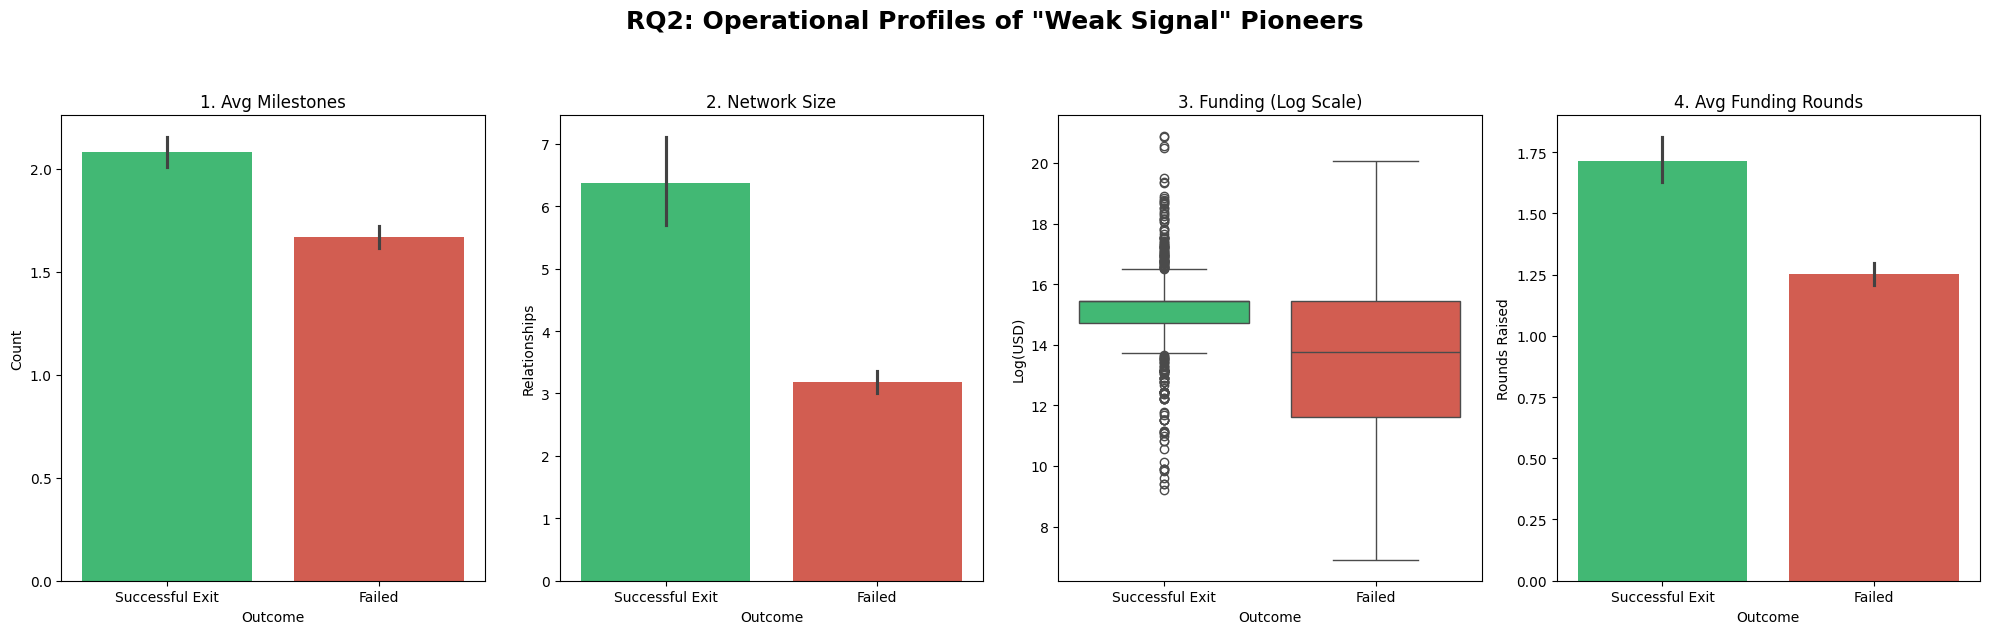

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Isolate ONLY the pioneers (Top 25% of Market Signal Scores)
pioneer_threshold = df_train['Market_Signal_Score'].quantile(0.75)
df_weak = df_train[df_train['Market_Signal_Score'] > pioneer_threshold].copy()

# ---> THIS IS THE MISSING LINE <---
df_weak['Outcome'] = df_weak['Target'].map({1: 'Successful Exit', 0: 'Failed'})

# Log transform funding
df_weak['log_funding'] = np.log1p(df_weak['funding_total_usd'])

# 1x4 grid
fig, axes = plt.subplots(1, 4, figsize=(20, 6)) 
fig.suptitle('RQ2: Operational Profiles of "Weak Signal" Pioneers', fontsize=18, fontweight='bold', y=1.05)

custom_palette = {'Failed': '#e74c3c', 'Successful Exit': '#2ecc71'}

# 1. Milestones 
sns.barplot(data=df_weak, x='Outcome', y='milestones', ax=axes[0], palette=custom_palette)
axes[0].set_title('1. Avg Milestones')
axes[0].set_ylabel('Count')

# 2. Relationships 
sns.barplot(data=df_weak, x='Outcome', y='relationships', ax=axes[1], palette=custom_palette)
axes[1].set_title('2. Network Size')
axes[1].set_ylabel('Relationships')

# 3. Total Funding 
sns.boxplot(data=df_weak, x='Outcome', y='log_funding', ax=axes[2], palette=custom_palette)
axes[2].set_title('3. Funding (Log Scale)')
axes[2].set_ylabel('Log(USD)')

# 4. Funding Rounds 
sns.barplot(data=df_weak, x='Outcome', y='funding_rounds', ax=axes[3], palette=custom_palette)
axes[3].set_title('4. Avg Funding Rounds')
axes[3].set_ylabel('Rounds Raised')

plt.tight_layout()
plt.show()

Generating SHAP values...


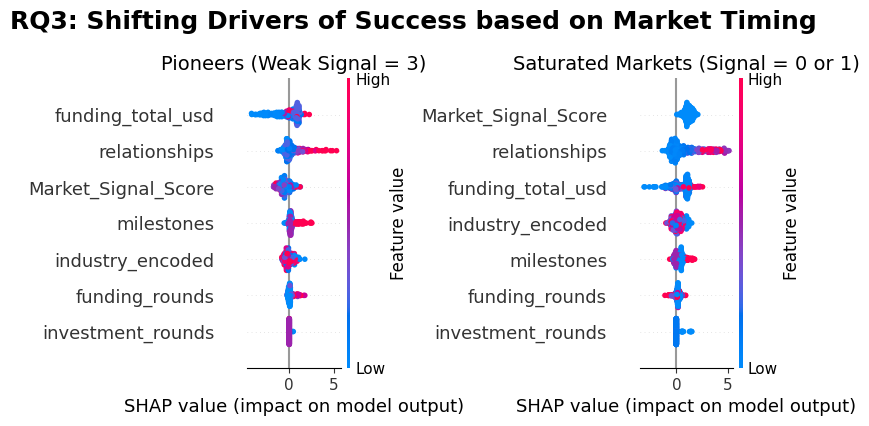

In [6]:
# RQ3: How do the drivers of success change depending on market timing?

print("Generating SHAP values...")
explainer = shap.TreeExplainer(xgb_aug)
shap_values = explainer.shap_values(X_aug_test)

# Define thresholds for the test set
thresh_high = X_aug_test['Market_Signal_Score'].quantile(0.75)
thresh_low = X_aug_test['Market_Signal_Score'].quantile(0.25)

mask_pioneer = X_aug_test['Market_Signal_Score'] > thresh_high
mask_saturated = X_aug_test['Market_Signal_Score'] <= thresh_low

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("RQ3: Shifting Drivers of Success based on Market Timing", fontsize=18, fontweight='bold')

plt.subplot(1, 2, 1)
plt.title("Pioneers (Weak Signal = 3)", fontsize=14)
shap.summary_plot(shap_values[mask_pioneer], X_aug_test[mask_pioneer], plot_type="dot", show=False)

plt.subplot(1, 2, 2)
plt.title("Saturated Markets (Signal = 0 or 1)", fontsize=14)
shap.summary_plot(shap_values[mask_saturated], X_aug_test[mask_saturated], plot_type="dot", show=False)

plt.tight_layout()
plt.show()

Decoding industries and generating Cross-Industry SHAP comparison...



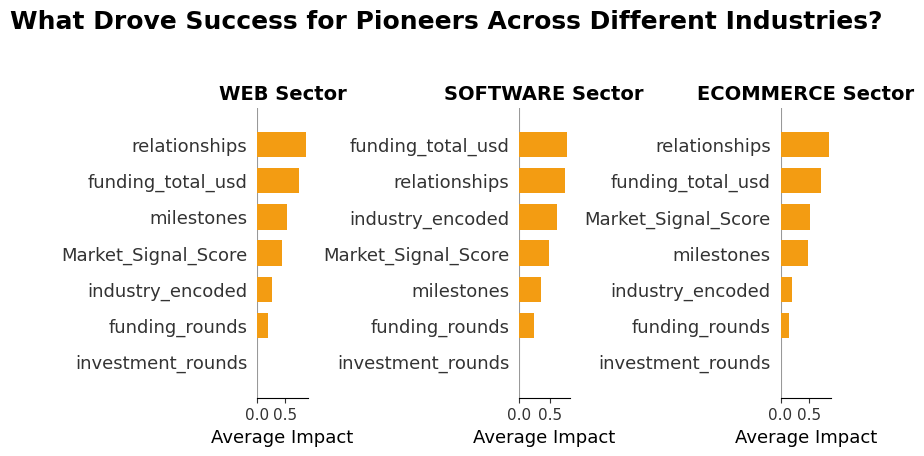

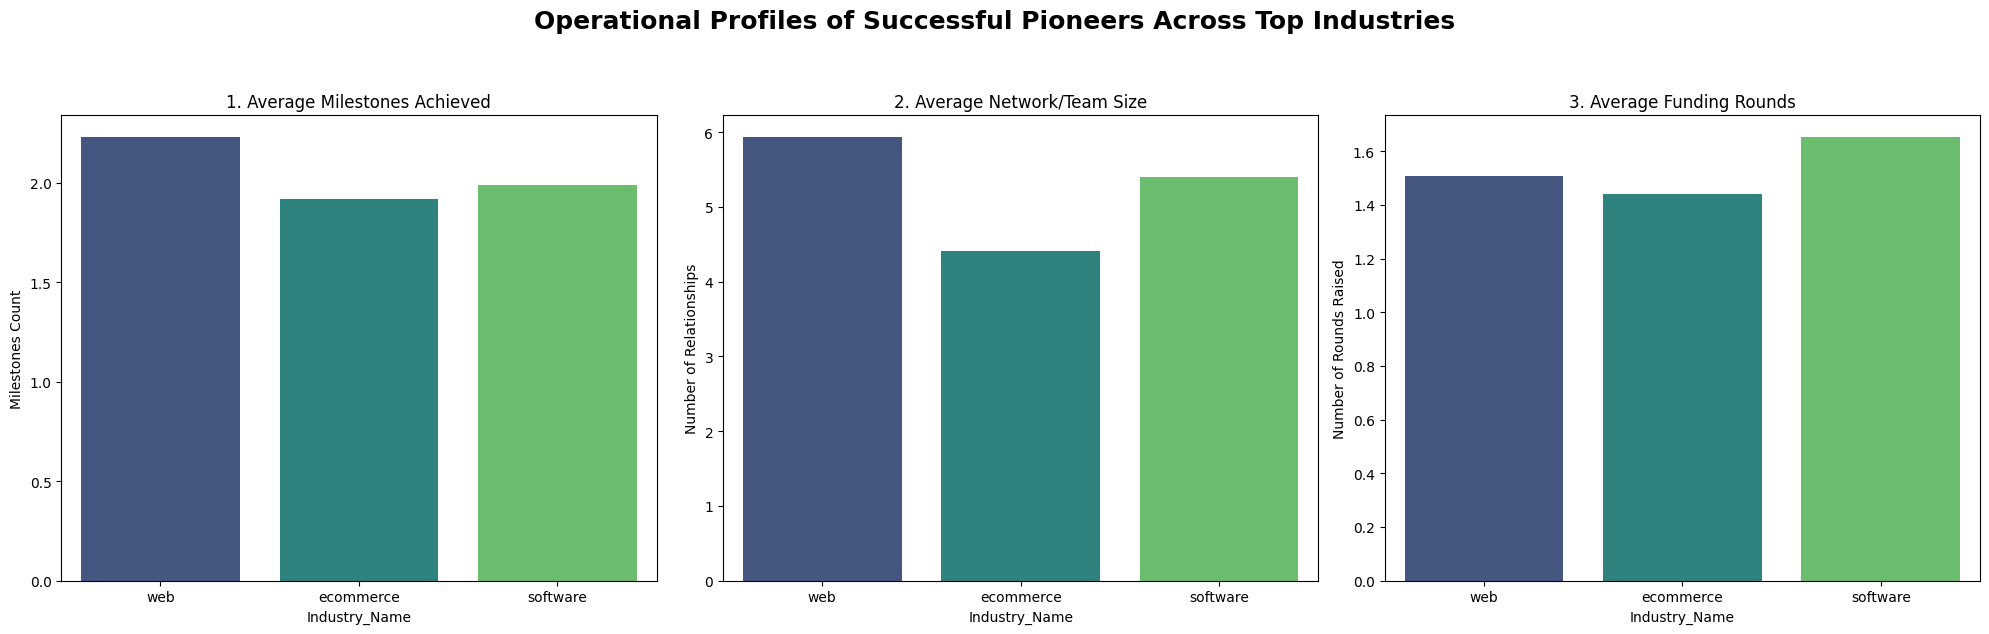

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pandas as pd
import numpy as np

# CROSS-INDUSTRY SHAP COMPARISON
print("Decoding industries and generating Cross-Industry SHAP comparison...\n")

industry_map = dict(zip(df_train['industry_encoded'], df_train['category_code'].fillna('Unknown')))
expected_cols = xgb_aug.feature_names_in_ 
X_full = df_train[expected_cols]
y_full = df_train['Target']

# 1. DEFINE THE VARIABLE HERE
global_pioneer_thresh = X_full['Market_Signal_Score'].quantile(0.75)
success_pioneer_mask = (X_full['Market_Signal_Score'] > global_pioneer_thresh) & (y_full == 1)
X_success_pioneers = X_full[success_pioneer_mask].copy()

# 2. USE THE VARIABLE HERE
top_industries = X_success_pioneers['industry_encoded'].value_counts().head(3).index.tolist()

shap.initjs()
explainer = shap.TreeExplainer(xgb_aug)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('What Drove Success for Pioneers Across Different Industries?', fontsize=18, fontweight='bold', y=1.05)

for i, ind_code in enumerate(top_industries):
    ind_name = industry_map.get(ind_code, "Unknown").upper()
    
    # 3. USE THE VARIABLE HERE AS WELL
    X_ind = X_success_pioneers[X_success_pioneers['industry_encoded'] == ind_code]
    shap_values_ind = explainer.shap_values(X_ind)
    
    plt.subplot(1, 3, i+1)
    plt.title(f"{ind_name} Sector", fontweight='bold', fontsize=14)
    shap.summary_plot(shap_values_ind, X_ind, plot_type="bar", show=False, color="#f39c12")
    plt.xlabel("Average Impact")

plt.tight_layout()
plt.show()




# 1. Isolate Successful Pioneers in the Top 3 Industries
df_top_inds = df_train[(df_train['Market_Signal_Score'] > global_pioneer_thresh) & 
                       (df_train['Target'] == 1) & 
                       (df_train['industry_encoded'].isin(top_industries))].copy()

# 2. Map industry numbers back to readable names
df_top_inds['Industry_Name'] = df_top_inds['industry_encoded'].map(industry_map)

# 3. Log transform funding so billion-dollar unicorns don't ruin the scale
df_top_inds['log_funding'] = np.log1p(df_top_inds['funding_total_usd'])

# Initialize 1 row, 3 columns to match your 3 metrics
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Operational Profiles of Successful Pioneers Across Top Industries', fontsize=18, fontweight='bold', y=1.05)

# 1. Milestones 
sns.barplot(data=df_top_inds, x='Industry_Name', y='milestones', ax=axes[0], palette='viridis', errorbar=None)
axes[0].set_title('1. Average Milestones Achieved')
axes[0].set_ylabel('Milestones Count')

# 2. Relationships 
sns.barplot(data=df_top_inds, x='Industry_Name', y='relationships', ax=axes[1], palette='viridis', errorbar=None)
axes[1].set_title('2. Average Network/Team Size')
axes[1].set_ylabel('Number of Relationships')

# 3. Funding Rounds
sns.barplot(data=df_top_inds, x='Industry_Name', y='funding_rounds', ax=axes[2], palette='viridis', errorbar=None)
axes[2].set_title('3. Average Funding Rounds')
axes[2].set_ylabel('Number of Rounds Raised')

plt.tight_layout()
plt.show()